In [3]:
import polars as pl
import numpy as np
import datetime as dt
import sf_quant.data as sfd
import sf_quant.research as sfr
import polars_ols
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd



In [4]:
start = dt.date(2000, 1, 1)
end = dt.date(2024, 12, 31)
signal_name = "IS2"
price_filter = 5
IC = 0.05

data = sfd.load_assets(
    start=start,
    end=end,
    columns=[
        "date",
        "barrid",
        "price",
        "return",
        "specific_risk",
        "predicted_beta",
        "market_cap",
        "daily_volume", 
        "specific_return"
    ],
    in_universe=True,
).with_columns(pl.col("return",  "specific_return", "specific_risk").truediv(100))

# T=5
# days=T*21

df = data.sort(["barrid", "date"])


# calculates turnover 
df = df.with_columns(
    (pl.col("daily_volume") / pl.col("market_cap")).alias("turnover")
)

# Get last trading day of each month per stock
df = df.with_columns([
    pl.col("date").cast(pl.Datetime).alias("date_dt"),
    pl.col("market_cap").log().alias("log_mktcap")
])

# Create month indicator
df = df.with_columns(
    (pl.col("date_dt").dt.year() * 100 + pl.col("date_dt").dt.month()).alias("yyyymm")
)

# last trading day per month
monthly_df = df.group_by(["barrid", "yyyymm"]).agg([
    pl.col("specific_return").last().alias("specific_return"),
    pl.col("turnover").mean().alias("turnover"),
    pl.col("log_mktcap").last().alias("log_mktcap"),
    pl.col("price").last().alias("price"),
    pl.col("predicted_beta").last().alias("predicted_beta"),
    pl.col("specific_risk").last().alias("specific_risk"),
    pl.col("date").last().alias("date"),
    pl.col("return").last().alias("return")
])

T = 12
monthly_df = monthly_df.sort(["barrid","yyyymm"])

# current period
monthly_df = monthly_df.with_columns([
    # MOMENTUM
    pl.col("specific_return").log1p().shift(1).rolling_sum(window_size=T).over("barrid").alias("curmom"),
    
    # volitility
    pl.col("specific_return").shift(1).rolling_std(window_size=T).over("barrid").alias("curvol"),
    
    # Skewness
    pl.col("specific_return").shift(1).rolling_skew(window_size=T).over("barrid").alias("curskew"),
    
    # Turnover
    pl.col("turnover").shift(1).rolling_mean(window_size=T).over("barrid").alias("curturn")])

# previous
monthly_df = monthly_df.with_columns([
    # MOMENTUM
    pl.col("specific_return").log1p().shift(1+T).rolling_sum(window_size=T).over("barrid").alias("prevmom"),
    
    # volitility
    pl.col("specific_return").shift(1+T).rolling_std(window_size=T).over("barrid").alias("prevvol"),
    
    # Skewness
    pl.col("specific_return").shift(1+T).rolling_skew(window_size=T).over("barrid").alias("prevskew"),
    
    # Turnover
    pl.col("turnover").shift(1+T).rolling_mean(window_size=T).over("barrid").alias("prevturn"),
    
    # mktcap
    pl.col("log_mktcap").shift(1+T).over("barrid").alias("prevlog_mktcap")])

    

# Drop rows with missing values
monthly_df = monthly_df.drop_nulls(["curmom", "curvol", "curskew", "curturn", "log_mktcap", "prevmom", "prevvol", "prevskew", "prevturn", "prevlog_mktcap"])

# ols per mounth
def cross_sectional_ols(df_month):
    X = df_month[["prevmom", "prevvol", "prevskew", "prevturn", "prevlog_mktcap"]]
    y = df_month["curskew"]  
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    coef_dict = model.params.to_dict()
    return model

# Shift skew by -1 month to get next month skew
monthly_df = monthly_df.sort(["barrid","yyyymm"])
monthly_df = monthly_df.with_columns(
    pl.col("curskew").shift(-1).over("barrid").alias("skew_next")  
)

monthly_df = monthly_df.drop_nulls(["skew_next"])

# run cross-sectional regression
coeffs_list = []
monthly= []
monthly_df = monthly_df.sort(["barrid","yyyymm"])


for month, df_month in monthly_df.group_by("yyyymm"):
    df_month_pd = df_month.to_pandas()
    model = cross_sectional_ols(df_month_pd)
    coeffs_list.append(model)
    params = model.params.to_dict()

    monthly.append([month[0], params['const'],params['prevmom'], params['prevvol'], params['prevskew'], params['prevturn'], params['prevlog_mktcap']])

# monthly1 has all of the monthly results of the regression, merges it onto monthly_df
monthly1 = pd.DataFrame(monthly, columns=['yyyymm', 'const', 'Bprevmom', 'Bprevvol', 'Bprevskew', 'Bprevturn', 'Bprevlog_mktcap'])
monthly1 = pl.from_pandas(monthly1)
monthly_df= monthly_df.join(monthly1, on='yyyymm', how='left')


avgcoeffs = monthly1[['const', 'Bprevmom', 'Bprevvol', 'Bprevskew', 'Bprevturn', 'Bprevlog_mktcap']].mean()
print(avgcoeffs)

# Compute expected skewness using past characteristics
monthly_df = monthly_df.with_columns(
    (
        pl.col("const")
        + pl.col("Bprevskew") * pl.col("curskew")
        + pl.col("Bprevvol") * pl.col("curvol")
        + pl.col("Bprevmom") * pl.col("curmom")
        + pl.col("Bprevturn") * pl.col("curturn")
        + pl.col("Bprevlog_mktcap") * pl.col("log_mktcap")
    ).alias(signal_name)
)




shape: (1, 6)
┌──────────┬──────────┬──────────┬───────────┬───────────┬─────────────────┐
│ const    ┆ Bprevmom ┆ Bprevvol ┆ Bprevskew ┆ Bprevturn ┆ Bprevlog_mktcap │
│ ---      ┆ ---      ┆ ---      ┆ ---       ┆ ---       ┆ ---             │
│ f64      ┆ f64      ┆ f64      ┆ f64       ┆ f64       ┆ f64             │
╞══════════╪══════════╪══════════╪═══════════╪═══════════╪═════════════════╡
│ 0.378307 ┆ -0.0358  ┆ 0.66189  ┆ 0.006074  ┆ 31.72917  ┆ -0.014384       │
└──────────┴──────────┴──────────┴───────────┴───────────┴─────────────────┘


In [52]:
# monthly_df

In [ ]:
# signal= monthly_df.with_columns(
#     pl.col("IS2").rank(method="average").over("date").alias("rank"))

# signal = signal.with_columns(
#     pl.count("IS2").over("date").alias("count_per_date"))

# signal = signal.with_columns(
#     ((pl.col("rank") / pl.col("count_per_date") * 5).ceil().cast(pl.Int32)).alias("quintile"))

# signal = signal.drop(["rank", "count_per_date"])
# signal.describe()
# signal= signal.filter(pl.col("quintile").is_not_null())
# signal

barrid,yyyymm,specific_return,turnover,log_mktcap,price,predicted_beta,specific_risk,date,return,curmom,curvol,curskew,curturn,prevmom,prevvol,prevskew,prevturn,prevlog_mktcap,skew_next,const,Bprevmom,Bprevvol,Bprevskew,Bprevturn,Bprevlog_mktcap,IS2,quintile
str,i32,f64,f64,f64,f64,f64,f64,date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32
"""USA06Z1""",201507,-0.0517,0.000292,20.853927,10.73,1.354733,0.428897,2015-07-31,-0.037668,0.039595,0.02507,0.486143,0.000215,0.031367,0.021163,0.172437,0.000295,20.422196,0.187701,0.31429,-0.248991,1.059366,-0.012939,59.635591,-0.010871,0.110827,4
"""USA06Z1""",201508,0.03565,0.000312,20.77918,9.71,1.27402,0.440315,2015-08-31,0.011458,-0.019034,0.029686,0.187701,0.000221,0.044823,0.020899,0.023918,0.000297,20.39648,-0.060531,0.322239,0.010715,0.258328,0.013812,64.373405,-0.009522,0.148676,4
"""USA06Z1""",201509,-0.01324,0.000258,20.772981,9.65,1.305522,0.42671,2015-09-30,0.020085,0.025207,0.031361,-0.060531,0.000233,0.063146,0.019027,0.167901,0.000298,20.415118,-0.058059,0.304192,0.073957,-0.296463,0.023122,67.102919,-0.008903,0.126083,3
"""USA06Z1""",201510,0.00098,0.000425,20.491154,7.28,1.53375,0.4584342,2015-10-30,-0.001372,0.024812,0.031379,-0.058059,0.000242,0.06486,0.018871,0.174956,0.000268,20.442468,-0.228143,0.26384,-0.240099,-0.744505,0.048504,100.132397,-0.007204,0.108329,3
"""USA06Z1""",201511,0.04006,0.000268,20.69928,8.96,1.611564,0.46629,2015-11-30,0.026346,-0.026544,0.026933,-0.228143,0.000257,0.106068,0.023458,0.433345,0.000264,20.798582,-0.210138,-0.01588,-0.673747,2.574374,0.035863,75.174098,0.003643,0.157857,5
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""USBOE91""",202411,-0.02908,0.000413,19.866522,9.47,1.151623,0.408867,2024-11-29,-0.02572,-0.04928,0.02294,0.415566,0.000472,0.029547,0.016203,-0.420977,0.000212,19.722485,0.44728,0.44119,-0.340993,0.551657,0.012633,130.117874,-0.020861,0.122863,5
"""USBOFX1""",202410,0.01275,0.000058,22.311752,49.76,1.525086,0.544961,2024-10-31,-0.013872,-0.031689,0.028158,-0.554762,0.00012,0.066375,0.037353,0.762114,0.000286,21.298151,-0.477115,0.579164,-0.408821,-0.77814,0.014946,86.135895,-0.024797,0.018978,2
"""USBOFX1""",202411,-0.01744,0.000052,22.260699,46.01,1.604573,0.541982,2024-11-29,-0.007978,0.04038,0.022288,-0.477115,0.000108,-0.073434,0.032672,0.343778,0.000285,21.476103,-0.155255,0.44119,-0.340993,0.551657,0.012633,130.117874,-0.020861,-0.016653,2


/tmp/ipykernel_1409493/3274013361.py:2: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  raw = (signal.group_by(["date", "quintile"]).agg(pl.col("IS2").mean()).pivot(


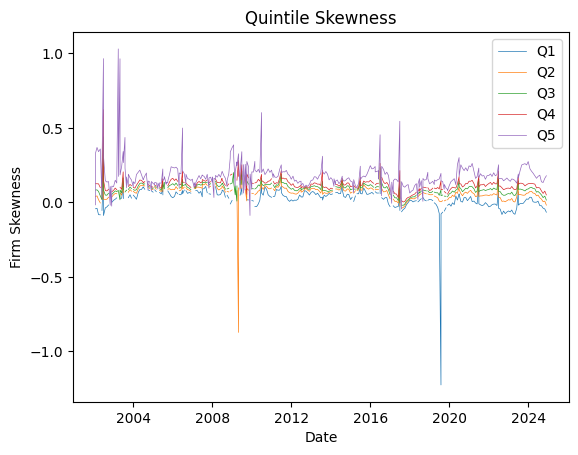

In [ ]:
# # shows expected skewness
# raw = (signal.group_by(["date", "quintile"]).agg(pl.col("IS2").mean()).pivot(
#         values="IS2",
#         index="date",
#         columns="quintile", sort_columns=True
#     )
#     .sort("date")
#     .with_columns(pl.exclude('date')))

# dates= raw['date']

# for col in raw.columns:
#     if col != "date":
#         plt.plot(dates, raw[col], label=f"Q{col}", linewidth=0.5)

# plt.legend()
# plt.xlabel("Date")

# plt.ylabel("Firm Skewness")
# plt.title("Quintile Skewness")
# plt.show()

In [ ]:
# ew = (signal.group_by(["date", "quintile"]).agg(pl.col("IS2").mean()).pivot(
#         values="IS2",
#         index="date",
#         columns="quintile", sort_columns=True
#     )
#     .sort("date")
#     .with_columns(pl.exclude('date')))

/tmp/ipykernel_1409493/3151554960.py:1: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  ew = (signal.group_by(["date", "quintile"]).agg(pl.col("IS2").mean()).pivot(


/tmp/ipykernel_1409493/430862856.py:5: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  ew = (signal.group_by(["date", "quintile"]).agg(pl.col("cum_ret").mean()).pivot(


shape: (355, 7)
┌────────────┬──────────┬──────────┬──────────┬──────────┬───────────┬───────────┐
│ date       ┆ 1        ┆ 2        ┆ 3        ┆ 4        ┆ 5         ┆ spread    │
│ ---        ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---       ┆ ---       │
│ date       ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f64       ┆ f64       │
╞════════════╪══════════╪══════════╪══════════╪══════════╪═══════════╪═══════════╡
│ 2002-01-30 ┆ null     ┆ null     ┆ null     ┆ null     ┆ 0.022923  ┆ null      │
│ 2002-01-31 ┆ 0.014574 ┆ 0.00656  ┆ 0.00753  ┆ 0.011369 ┆ 0.026941  ┆ -0.012367 │
│ 2002-02-28 ┆ 0.013024 ┆ 0.004464 ┆ 0.003478 ┆ 0.007084 ┆ 0.009505  ┆ 0.003519  │
│ 2002-03-28 ┆ 0.015759 ┆ 0.00751  ┆ 0.003885 ┆ 0.009925 ┆ 0.006934  ┆ 0.008826  │
│ 2002-04-30 ┆ 0.027824 ┆ 0.021758 ┆ 0.022694 ┆ 0.027934 ┆ 0.027768  ┆ 0.000056  │
│ …          ┆ …        ┆ …        ┆ …        ┆ …        ┆ …         ┆ …         │
│ 2024-07-31 ┆ 0.151983 ┆ 0.134525 ┆ 0.166364 ┆ 0.058355 ┆ -0.612988 ┆ 

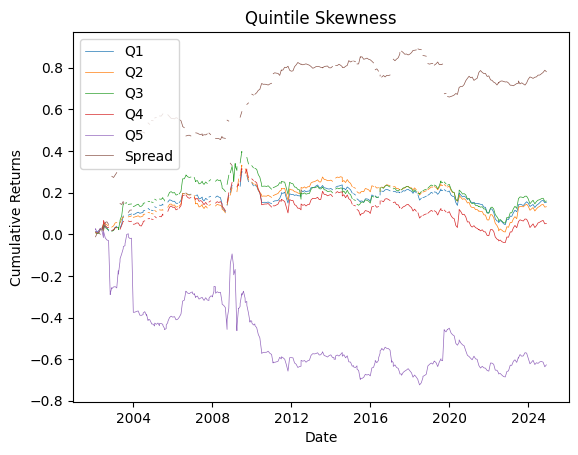

In [ ]:
# signal = signal.group_by(['date', 'quintile']).agg(pl.col('return').mean().alias('quint_ret')).sort(['quintile', 'date'])
# signal = signal.with_columns(pl.col('quint_ret').log1p().cum_sum().over('quintile').alias('cum_ret'))


# ew = (signal.group_by(["date", "quintile"]).agg(pl.col("cum_ret").mean()).pivot(
#         values="cum_ret",
#         index="date",
#         columns="quintile", sort_columns=True
#     )
#     .sort("date")
#     .with_columns(pl.exclude('date')))

# ew = ew.with_columns((pl.col('1')-pl.col('5')).alias('spread'))
# print(ew)

# dates= ew['date']

# for col in ew.columns:
#     if col != "date" and col != 'spread':
#         plt.plot(dates, ew[col], label=f"Q{col}", linewidth=0.5)
#     if col == "spread":
#         plt.plot(dates, ew[col], label=f"Spread", linewidth=0.5)

# plt.legend()
# plt.xlabel("Date")
# # plt.ylim(-1,1)
# plt.ylabel("Cumulative Returns")
# plt.title("Quintile Skewness")
# plt.show()

In [8]:
# does vol scaling


# 1. Calculate Rolling Volatility (using a 12-month window as an example)
# It is vital to sort by barrid and date for the rolling window to work
monthly_df = monthly_df.sort(["barrid", "date"])

monthly_df = monthly_df.with_columns(
    pl.col("return")
    .rolling_std(window_size=12)
    .over("barrid")
    .alias("vol")
)

# 2. Apply Signal Scaling
# We use a small epsilon or fill_null to avoid division by zero/nulls
signal_scaled = monthly_df.with_columns(
    (pl.col("IS2") / pl.col("vol")).alias("scaled_IS2")
).filter(pl.col("scaled_IS2").is_not_null() & pl.col("scaled_IS2").is_finite())

# 3. Create Quintiles based on the SCALED signal
signal_scaled = signal_scaled.with_columns(
    pl.col("scaled_IS2").rank(method="average").over("date").alias("rank")
)

signal_scaled = signal_scaled.with_columns(
    ((pl.col("rank") / pl.col("scaled_IS2").count().over("date") * 5).ceil().cast(pl.Int32))
    .alias("quintile")
)

# 4. Aggregate Equal-Weighted Returns per Quintile
# Even though the signal is scaled, we usually calculate EW returns 
# of the resulting buckets to see the effect of the scaling.
quintile_rets = (
    signal_scaled.group_by(["date", "quintile"])
    .agg(pl.col("return").mean().alias("quint_ret"))
    .sort(["date", "quintile"])
)

# 5. Cumulative Returns for plotting
ew_final = (
    quintile_rets.with_columns(
        pl.col("quint_ret").log1p().cum_sum().over("quintile").alias("cum_ret")
    )
    .pivot(values="cum_ret", index="date", on="quintile", sort_columns=True)
    .sort("date")
)

# 6. Calculate the Long/Short Spread
ew_final = ew_final.with_columns((pl.col('1') - pl.col('5')).alias('spread'))

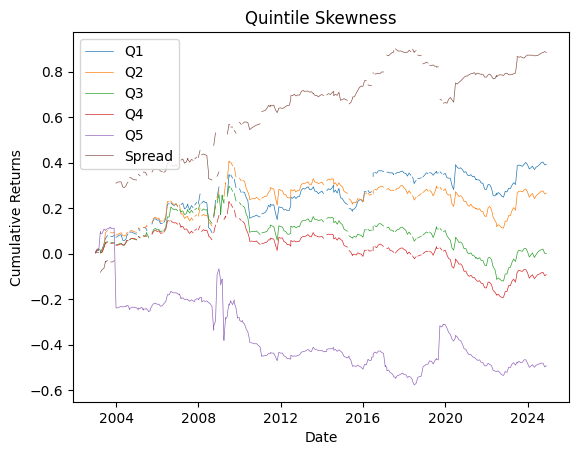

In [9]:
ew_final


dates= ew_final['date']

for col in ew_final.columns:
    if col != "date" and col != 'spread':
        plt.plot(dates, ew_final[col], label=f"Q{col}", linewidth=0.5)
    if col == "spread":
        plt.plot(dates, ew_final[col], label=f"Spread", linewidth=0.5)

plt.legend()
plt.xlabel("Date")
# plt.ylim(-1,1)
plt.ylabel("Cumulative Returns")
plt.title("Quintile Skewness")
plt.show()